In [1]:
!pip -q install timm==1.0.9 PyWavelets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 32.4 MB/s eta 0:00:0000:0100:01


In [ ]:
import random
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from PIL import Image
import pywt
import timm
from tqdm.auto import tqdm

In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

COMPUTE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {COMPUTE_DEVICE}")

Device: cuda


In [ ]:
PRIMARY_DATASET_DIR = Path("/kaggle/input/datasets/ebtesamalshemmary/brain-tumor-mri-classification")

TRAINING_IMAGES_DIR = PRIMARY_DATASET_DIR / "Training" / "Training"
TEST_IMAGES_DIR = PRIMARY_DATASET_DIR / "Testing"  / "Testing"

EXTERNAL_DATASET_DIR = Path("/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri")
EXTERNAL_TEST_IMAGES_DIR = EXTERNAL_DATASET_DIR / "Testing"

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(exist_ok=True)

CLASS_LABELS = ["glioma", "meningioma", "notumor", "pituitary"]

EXTERNAL_LABEL_MAP = {
    "glioma_tumor": 0,
    "meningioma_tumor": 1,
    "no_tumor": 2,
    "pituitary_tumor": 3,
}

N_CLASSES = 4

SWIN_BACKBONE_NAME = "swin_base_patch4_window7_224.ms_in22k_ft_in1k"

N_EPOCHS = 40
LEARNING_RATE = 3e-5
BATCH_SIZE = 32

WAVELET_LEVELS = 3
WARMUP_STAGE_EPOCHS = 5 

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

In [5]:
from kaggle_secrets import UserSecretsClient
import os

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("token")

os.environ["HF_TOKEN"] = hf_token
os.environ["HUGGINGFACE_HUB_TOKEN"] = hf_token

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(15),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

validation_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
class ImagePathDataset(Dataset):
    def __init__(self, image_paths, image_labels, transform):
        self.image_paths = [str(p) for p in image_paths]
        self.image_labels = image_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, i):
        img = Image.open(self.image_paths[i]).convert("RGB")
        img = self.transform(img)
        label = int(self.image_labels[i])

        return img, label

In [ ]:
def load_image_paths(root_dir, folder_map):
    paths = []
    labels = []

    for folder, label in folder_map.items():
        d = root_dir / folder

        if not d.exists():
            print(f"[WARNING] не знайдено: {d}")
            continue

        files = sorted(
            f for ext in ("*.jpg", "*.jpeg", "*.png")
            for f in d.rglob(ext)
        )

        paths.extend(files)
        labels.extend([label] * len(files))

        print(f"  {folder}: {len(files)}")

    return paths, np.array(labels, dtype=np.int64)


train_dataset = datasets.ImageFolder(
    str(TRAINING_IMAGES_DIR),
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    str(TEST_IMAGES_DIR),
    transform=validation_transform
)

external_paths, y_external = load_image_paths(
    EXTERNAL_TEST_IMAGES_DIR,
    EXTERNAL_LABEL_MAP
)

external_dataset = ImagePathDataset(
    external_paths,
    y_external,
    validation_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

external_loader = DataLoader(
    external_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

y_test = np.array([lbl for _, lbl in test_dataset.samples])

print(f"Train: {len(train_dataset)}  Test: {len(test_dataset)}  External: {len(external_dataset)}")

  glioma_tumor: 100
  meningioma_tumor: 115
  no_tumor: 105
  pituitary_tumor: 74
Train: 32080  Test: 8020  External: 394


In [ ]:
# wavelet branch (db4)
class LearnableDaubechies4Branch(nn.Module):
    def __init__(self, levels: int = 3, output_dim: int = 256):
        super().__init__()

        self.levels = levels

        db4 = pywt.Wavelet("db4")
        lp = torch.tensor(db4.dec_lo, dtype=torch.float32)
        hp = torch.tensor(db4.dec_hi, dtype=torch.float32)

        base = torch.stack([
            torch.outer(lp, lp),
            torch.outer(lp, hp),
            torch.outer(hp, lp),
            torch.outer(hp, hp),
        ], dim=0).unsqueeze(1)

        self.level_filters = nn.ParameterList([
            nn.Parameter(base.clone())
            for _ in range(levels)
        ])

        self.pool = nn.AdaptiveAvgPool2d(7)

        flat_dim = (1 + 3 * levels) * 7 * 7

        self.projection = nn.Sequential(
            nn.Linear(flat_dim, output_dim * 2),
            nn.LayerNorm(output_dim * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(output_dim * 2, output_dim),
            nn.LayerNorm(output_dim),
        )

    def forward(self, x):
        # grayscale
        gray = (
            0.2989 * x[:, 0:1] +
            0.5870 * x[:, 1:2] +
            0.1140 * x[:, 2:3]
        )

        cur = gray
        pooled = []

        for lvl in range(self.levels):
            out = F.conv2d(cur, self.level_filters[lvl], stride=2, padding=3)

            for d in [1, 2, 3]:
                p = self.pool(out[:, d:d+1])
                pooled.append(p.view(p.size(0), -1))

            cur = out[:, 0:1]

        p = self.pool(cur)
        pooled.append(p.view(p.size(0), -1))

        return self.projection(torch.cat(pooled, dim=1))


# swin + db4
class SwinDaubechies4(nn.Module):
    def __init__(self, num_classes=4, wav_dim=256, dropout=0.1):
        super().__init__()

        self.swin = timm.create_model(
            SWIN_BACKBONE_NAME,
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )

        swin_dim = self.swin.num_features

        self.wav_branch = LearnableDaubechies4Branch(
            levels=WAVELET_LEVELS,
            output_dim=wav_dim
        )
        
        self.gate = nn.Sequential(
            nn.Linear(swin_dim, 1),
            nn.Sigmoid()
        )

        self.head = nn.Sequential(
            nn.LayerNorm(swin_dim + wav_dim),
            nn.Dropout(dropout),
            nn.Linear(swin_dim + wav_dim, num_classes),
        )

        n_train = sum(p.numel() for p in self.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in self.parameters())

        print(f"SwinDaubechies4: {n_train:,} / {n_total:,} params ({100*n_train/n_total:.1f}%)")

    def forward(self, x):
        sf = self.swin(x)
        wf = self.wav_branch(x)
        wf = self.gate(sf) * wf
        return self.head(torch.cat([sf, wf], dim=1))

In [ ]:
#mixup аугментація
def mixup_data(imgs, labels, alpha=0.2):
 
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(imgs.size(0), device=imgs.device)

    mixed_imgs = lam * imgs + (1 - lam) * imgs[idx]

    return mixed_imgs, labels, labels[idx], lam


def mixup_loss(loss_fn, logits, la, lb, lam):
    loss_a = loss_fn(logits, la)
    loss_b = loss_fn(logits, lb)

    return lam * loss_a + (1 - lam) * loss_b

#навчання протягом епохи
def train_epoch(model, loader, loss_fn, optimizer, scaler, scheduler):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for imgs, lbls in tqdm(loader, leave=False, desc="train"):
        imgs = imgs.to(COMPUTE_DEVICE)
        lbls = lbls.to(COMPUTE_DEVICE)

        use_mix = random.random() < 0.5

        if use_mix:
            imgs, la, lb, lam = mixup_data(imgs, lbls)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=COMPUTE_DEVICE.type == "cuda"):
            logits = model(imgs)

            if use_mix:
                loss = mixup_loss(loss_fn, logits, la, lb, lam)
            else:
                loss = loss_fn(logits, lbls)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        preds = logits.argmax(1)

        total_loss += loss.item() * imgs.size(0)

        if use_mix:
            correct += (preds == la).sum().item()
        else:
            correct += (preds == lbls).sum().item()

        total += imgs.size(0)

    return total_loss / total, correct / total

#оцінка 
@torch.no_grad()
def eval_epoch(model, loader, loss_fn):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    for imgs, lbls in tqdm(loader, leave=False, desc="eval"):
        imgs = imgs.to(COMPUTE_DEVICE)
        lbls = lbls.to(COMPUTE_DEVICE)

        with torch.cuda.amp.autocast(enabled=COMPUTE_DEVICE.type == "cuda"):
            logits = model(imgs)
            loss = loss_fn(logits, lbls)

        probs = torch.softmax(logits, 1)
        preds = logits.argmax(1)

        total_loss += loss.item() * imgs.size(0)

        correct += (preds == lbls).sum().item()
        total += imgs.size(0)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(lbls.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    return (
        total_loss / total,
        correct / total,
        np.concatenate(all_preds),
        np.concatenate(all_labels),
        np.vstack(all_probs),
    )

#перенавчання
class EarlyStopping:
    def __init__(self,
                 patience_loss=5,
                 patience_acc=7,
                 patience_gap=3,
                 gap_window=5,
                 min_delta=1e-4,
                 gap_threshold=0.10):

        self.pl = patience_loss
        self.pa = patience_acc
        self.pg = patience_gap

        self.gw = gap_window
        self.md = min_delta
        self.gt = gap_threshold

        self.best_loss = float("inf")
        self.best_acc = 0.0

        self.lc = 0
        self.ac = 0

        self.gap_hist = []
        self.stop = False
        self.reason = ""

    def step(self, val_loss, val_acc, tr_acc):
        if self.stop:
            return "stop"

        # перевірка validation loss
        if val_loss < self.best_loss - self.md:
            self.best_loss = val_loss
            self.lc = 0
        else:
            self.lc += 1

        if self.lc >= self.pl:
            self.stop = True
            self.reason = f"loss не покращується {self.pl} епох"
            return "stop"

        # перевірка validation accuracy
        if val_acc > self.best_acc + self.md:
            self.best_acc = val_acc
            self.ac = 0
        else:
            self.ac += 1

        if self.ac >= self.pa:
            self.stop = True
            self.reason = f"accuracy не покращується {self.pa} епох"
            return "stop"

        gap = tr_acc - val_acc

        self.gap_hist.append(gap > self.gt)
        self.gap_hist = self.gap_hist[-self.gw:]

        bad = sum(self.gap_hist)

        if bad >= self.pg:
            self.stop = True
            self.reason = f"перенавчання {bad}/{self.gw} епох"
            return "stop"

        if bad > 0:
            return "warn"

        return ""

In [ ]:
@torch.no_grad()
def eval_with_tta(model, image_paths, labels_array, n_tta=5):
    model.eval()

    # tta трансформації
    tta_transforms = [
        validation_transform,

        transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]),

        transforms.Compose([
            transforms.Resize(232),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]),

        transforms.Compose([
            transforms.Resize(248),
            transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]),

        transforms.Compose([
            transforms.Resize(256),
            transforms.RandomCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]),
    ]

    labels_array = np.asarray(labels_array)
    acc_probs = None

    for tf in tta_transforms[:n_tta]:
        ds = ImagePathDataset(
            [str(p) for p in image_paths],
            labels_array,
            tf
        )

        ld = DataLoader(
            ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        probs = []

        for batch, _ in ld:
            batch = batch.to(COMPUTE_DEVICE)

            with torch.cuda.amp.autocast(enabled=COMPUTE_DEVICE.type == "cuda"):
                logits = model(batch)

            probs.append(torch.softmax(logits, 1).cpu().numpy())

        cur = np.vstack(probs)

        if acc_probs is None:
            acc_probs = cur
        else:
            acc_probs += cur

    acc_probs /= n_tta
    preds = acc_probs.argmax(1)

    return accuracy_score(labels_array, preds), preds, labels_array, acc_probs

In [ ]:
model = SwinDaubechies4(num_classes=N_CLASSES).to(COMPUTE_DEVICE)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)
scaler = torch.cuda.amp.GradScaler(enabled=COMPUTE_DEVICE.type == "cuda")


#оновлюються тільки wav_branch, gate, head
for p in model.swin.parameters():
    p.requires_grad = False


s1_opt = torch.optim.AdamW([
    {"params": model.wav_branch.parameters(), "lr": 1e-3},
    {"params": model.gate.parameters(),       "lr": 1e-3},
    {"params": model.head.parameters(),       "lr": 1e-3},
], weight_decay=1e-4)


s1_sched = torch.optim.lr_scheduler.OneCycleLR(
    s1_opt,
    max_lr=1e-3,
    total_steps=WARMUP_STAGE_EPOCHS * len(train_loader),
    pct_start=0.3,
    anneal_strategy="cos",
)


print(f"\n{'Epoch':>6}  {'Train Loss':>11}  {'Train Acc':>10}  {'Val Acc':>9}")
print("-" * 45)


for epoch in range(1, WARMUP_STAGE_EPOCHS + 1):
    tl, ta = train_epoch(
        model,
        train_loader,
        loss_fn,
        s1_opt,
        scaler,
        s1_sched
    )

    _, va, _, _, _ = eval_epoch(
        model,
        test_loader,
        loss_fn
    )

    print(f"[{epoch:>2}/{WARMUP_STAGE_EPOCHS}]  {tl:>11.4f}  {ta:>10.4f}  {va:>9.4f}")

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

SwinDaubechies4: 87,136,957 / 87,136,957 params (100.0%)

 Epoch   Train Loss   Train Acc    Val Acc
---------------------------------------------


train:   0%|          | 0/1003 [00:00<?, ?it/s]

eval:   0%|          | 0/251 [00:00<?, ?it/s]

[ 1/5]       0.8148      0.6213     0.8334


...

eval:   0%|          | 0/251 [00:00<?, ?it/s]

[ 4/5]       0.5910      0.7396     0.8789


train:   0%|          | 0/1003 [00:00<?, ?it/s]

eval:   0%|          | 0/251 [00:00<?, ?it/s]

[ 5/5]       0.5893      0.7249     0.8915


In [ ]:
# донавчаються всі частини моделі
for p in model.swin.parameters():
    p.requires_grad = True


swin_params = [p for n, p in model.named_parameters() if n.startswith("swin.")]
wav_params = [p for n, p in model.named_parameters() if "wav_branch" in n or "gate" in n]
head_params = [p for n, p in model.named_parameters() if n.startswith("head.")]


optimizer = torch.optim.AdamW([
    {"params": swin_params, "lr": LEARNING_RATE},
    {"params": wav_params,  "lr": LEARNING_RATE * 3},
    {"params": head_params, "lr": LEARNING_RATE * 10},
], weight_decay=1e-4)


total_steps = N_EPOCHS * len(train_loader)
warmup_steps = int(0.10 * total_steps)


def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)

    p = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * p)))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


es = EarlyStopping()
best_acc = 0.0
best_path = OUTPUT_DIR / "swin_db4_best.pt"

history = {
    "tl": [],
    "ta": [],
    "vl": [],
    "va": [],
    "gap": [],
}


print(f"\n{'Epoch':>6}  {'Train Loss':>11}  {'Train Acc':>10}  {'Val Loss':>10}  {'Val Acc':>9}  {'Gap':>7}  Status")
print("-" * 85)


for epoch in range(1, N_EPOCHS + 1):
    tl, ta = train_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        scaler,
        scheduler
    )

    vl, va, _, _, _ = eval_epoch(
        model,
        test_loader,
        loss_fn
    )

    gap = ta - va
    status = es.step(vl, va, ta)

    history["tl"].append(tl)
    history["ta"].append(ta)
    history["vl"].append(vl)
    history["va"].append(va)
    history["gap"].append(gap)

    saved = ""

    # зберігаємо найкращу модель
    if va > best_acc:
        best_acc = va

        torch.save(
            {
                "epoch": epoch,
                "state": model.state_dict(),
                "val_acc": va,
            },
            best_path
        )

        saved = "saved"

    tag = {
        "warn": " [overfit warn]",
        "stop": " [early stop]",
    }.get(status, "")

    print(f"[{epoch:>2}/{N_EPOCHS}]  {tl:>11.4f}  {ta:>10.4f}  {vl:>10.4f}  {va:>9.4f}  {gap:>+7.3f}{saved}{tag}")

    if status == "stop":
        print(f"\nEarly stopping: {es.reason}")
        break


print(f"\nНайкраща val accuracy: {best_acc:.4f}")


 Epoch   Train Loss   Train Acc    Val Loss    Val Acc      Gap  Status
-------------------------------------------------------------------------------------


train:   0%|          | 0/1003 [00:00<?, ?it/s]

eval:   0%|          | 0/251 [00:00<?, ?it/s]

[ 1/40]       0.4292      0.7950      0.2949     0.9732   -0.178saved


train:   0%|          | 0/1003 [00:00<?, ?it/s]

...

[31/40]       0.2856      0.8270      0.2044     0.9991   -0.172


train:   0%|          | 0/1003 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79f2a6b55da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x79f2a6b55da0>self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

    if w.is_alive():  
            ^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'

  File "/usr/lib/python

eval:   0%|          | 0/251 [00:00<?, ?it/s]

[32/40]       0.2826      0.8203      0.2033     0.9993   -0.179 [early stop]

Early stopping: loss не покращується 5 епох

Найкраща val accuracy: 0.9996


In [14]:
ckpt = torch.load(best_path, map_location=COMPUTE_DEVICE)
model.load_state_dict(ckpt["state"])
model.eval()
print(f"Завантажено epoch {ckpt['epoch']} (val_acc={ckpt['val_acc']:.4f})")

Завантажено epoch 27 (val_acc=0.9996)


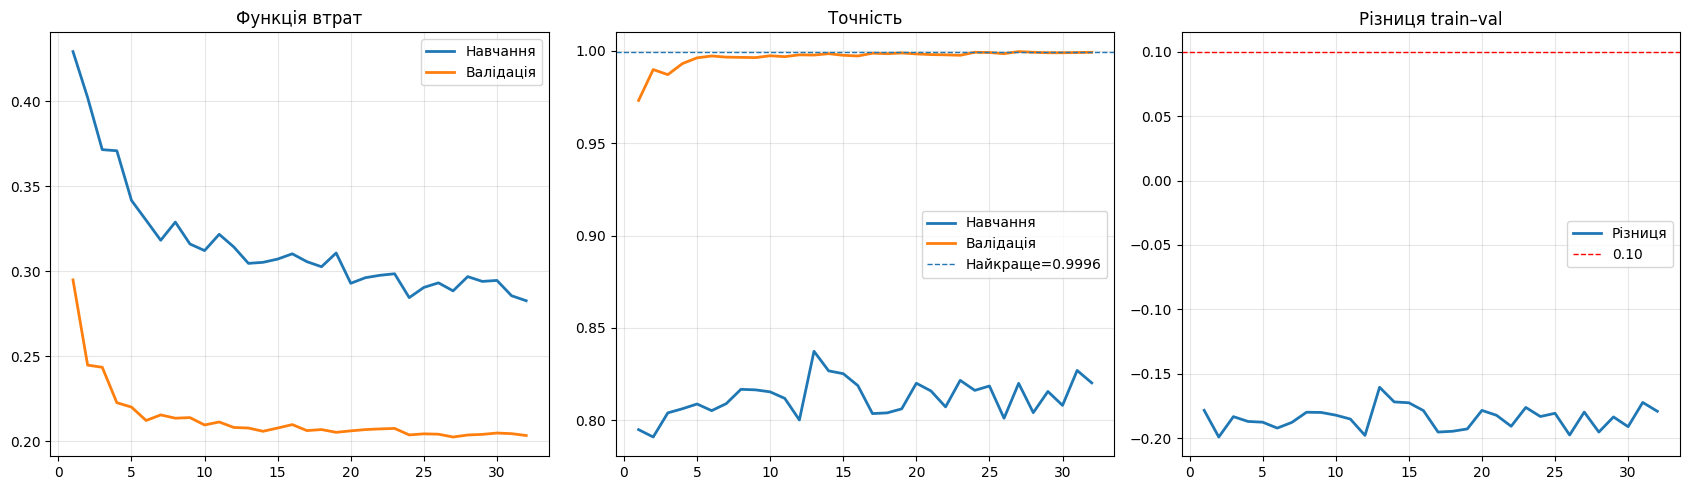

In [ ]:
epochs = range(1, len(history["tl"]) + 1)
gap = np.array(history["gap"])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(epochs, history["tl"], label="Навчання", lw=2)
axes[0].plot(epochs, history["vl"], label="Валідація", lw=2)
axes[0].set_title("Функція втрат")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["ta"], label="Навчання", lw=2)
axes[1].plot(epochs, history["va"], label="Валідація", lw=2)
axes[1].axhline(best_acc, ls="--", lw=1, label=f"Найкраще={best_acc:.4f}")
axes[1].set_title("Точність")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs, gap, lw=2, label="Різниця")
axes[2].axhline(0.10, ls="--", lw=1, color="red", label="0.10")
axes[2].fill_between(epochs, 0, gap, where=gap > 0.10, alpha=0.2)
axes[2].set_title("Різниця train–val")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
_, _, plain_test_preds, _, _ = eval_epoch(model, test_loader, loss_fn)
_, _, plain_ext_preds,  _, _ = eval_epoch(model, external_loader, loss_fn)

test_image_paths = [s[0] for s in test_dataset.samples]

_, tta_test_preds, _, _ = eval_with_tta(
    model,
    test_image_paths,
    y_test,
    n_tta=5
)

_, tta_ext_preds, _, _ = eval_with_tta(
    model,
    [str(p) for p in external_paths],
    y_external,
    n_tta=5
)

print(f"Test  plain  accuracy: {accuracy_score(y_test,     plain_test_preds):.4f}")
print(f"Test  TTA×5  accuracy: {accuracy_score(y_test,     tta_test_preds):.4f}")
print(f"Ext   plain  accuracy: {accuracy_score(y_external, plain_ext_preds):.4f}")
print(f"Ext   TTA×5  accuracy: {accuracy_score(y_external, tta_ext_preds):.4f}")

eval:   0%|          | 0/251 [00:00<?, ?it/s]

eval:   0%|          | 0/13 [00:00<?, ?it/s]

Test  plain  accuracy: 0.9996
Test  TTA×5  accuracy: 0.9996
Ext   plain  accuracy: 0.7919
Ext   TTA×5  accuracy: 0.8020


In [ ]:
def report(y_true, y_pred, title):
    print("\n" + "=" * 65)
    print(title)
    print("=" * 65)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=CLASS_LABELS,
            digits=4,
            zero_division=0
        )
    )

report(y_test, plain_test_preds, "TEST — Swin&Daubechies4 (plain)")
report(y_test, tta_test_preds,   "TEST — Swin&Daubechies4 (TTA×5)")

report(y_external, plain_ext_preds, "EXTERNAL — Swin&Daubechies4 (plain)")
report(y_external, tta_ext_preds,   "EXTERNAL — Swin&Daubechies4 (TTA×5)")


TEST — Swin&Daubechies4 (plain)
              precision    recall  f1-score   support

      glioma     1.0000    0.9995    0.9997      1886
  meningioma     0.9995    0.9989    0.9992      1879
     notumor     1.0000    1.0000    1.0000      2317
   pituitary     0.9990    1.0000    0.9995      1938

    accuracy                         0.9996      8020
   macro avg     0.9996    0.9996    0.9996      8020
weighted avg     0.9996    0.9996    0.9996      8020


TEST — Swin&Daubechies4 (TTA×5)
              precision    recall  f1-score   support

      glioma     1.0000    0.9995    0.9997      1886
  meningioma     0.9995    0.9989    0.9992      1879
     notumor     1.0000    1.0000    1.0000      2317
   pituitary     0.9990    1.0000    0.9995      1938

    accuracy                         0.9996      8020
   macro avg     0.9996    0.9996    0.9996      8020
weighted avg     0.9996    0.9996    0.9996      8020


EXTERNAL — Swin&Daubechies4 (plain)
              precision    

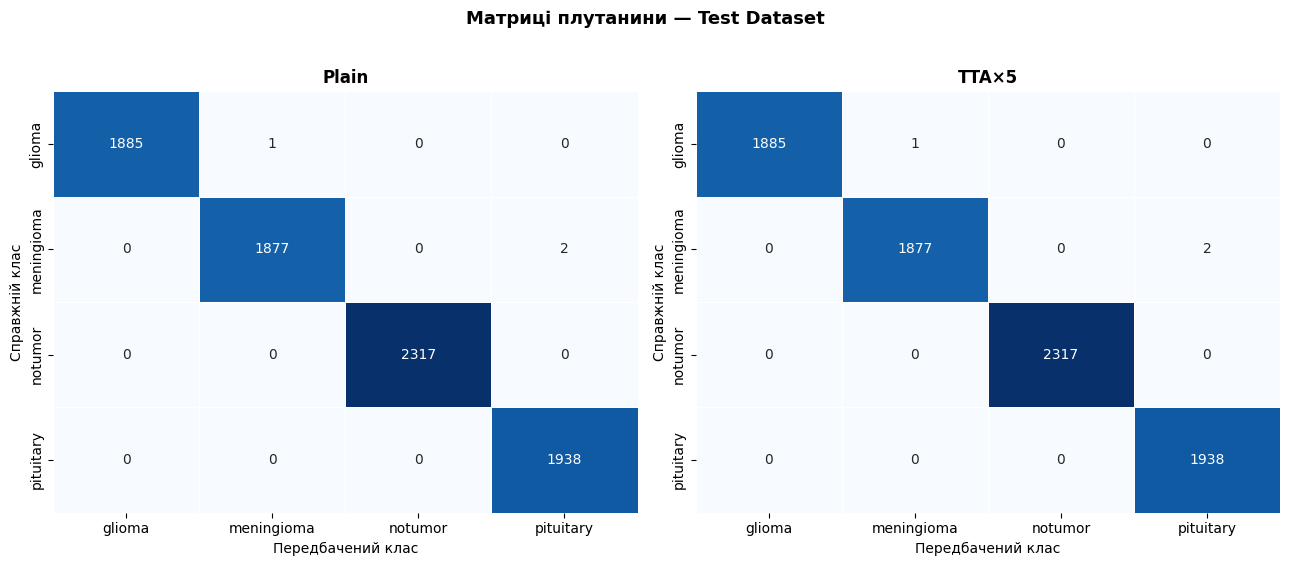

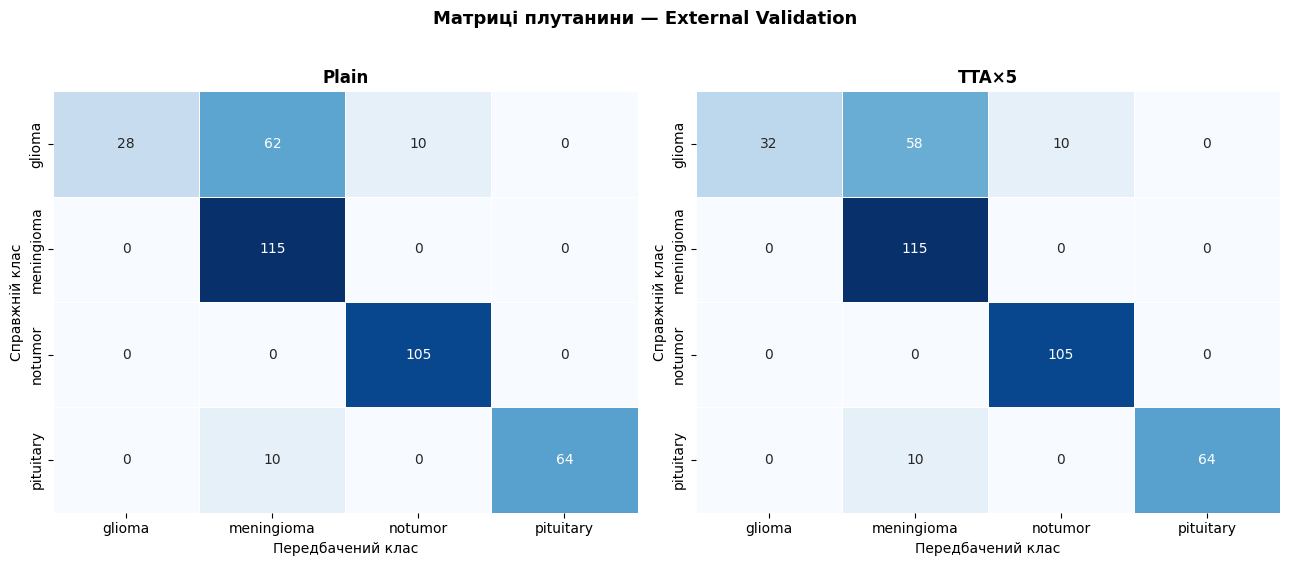

In [ ]:
def plot_cm(data, class_names, title, save_path=None):
    n = len(data)

    fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 5.5))
    if n == 1:
        axes = [axes]

    for ax, (name, (yt, yp)) in zip(axes, data.items()):
        cm = confusion_matrix(yt, yp)

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5,
            cbar=False,
            ax=ax
        )

        ax.set_title(name, fontsize=12, fontweight="bold")
        ax.set_xlabel("Передбачений клас")
        ax.set_ylabel("Справжній клас")

    plt.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

plot_cm(
    {
        "Plain": (y_test, plain_test_preds),
        "TTA×5": (y_test, tta_test_preds),
    },
    CLASS_LABELS,
    "Матриці плутанини — Test Dataset",
    save_path=OUTPUT_DIR / "confusion_test.png",
)

plot_cm(
    {
        "Plain": (y_external, plain_ext_preds),
        "TTA×5": (y_external, tta_ext_preds),
    },
    CLASS_LABELS,
    "Матриці плутанини — External Validation",
    save_path=OUTPUT_DIR / "confusion_external.png",
)

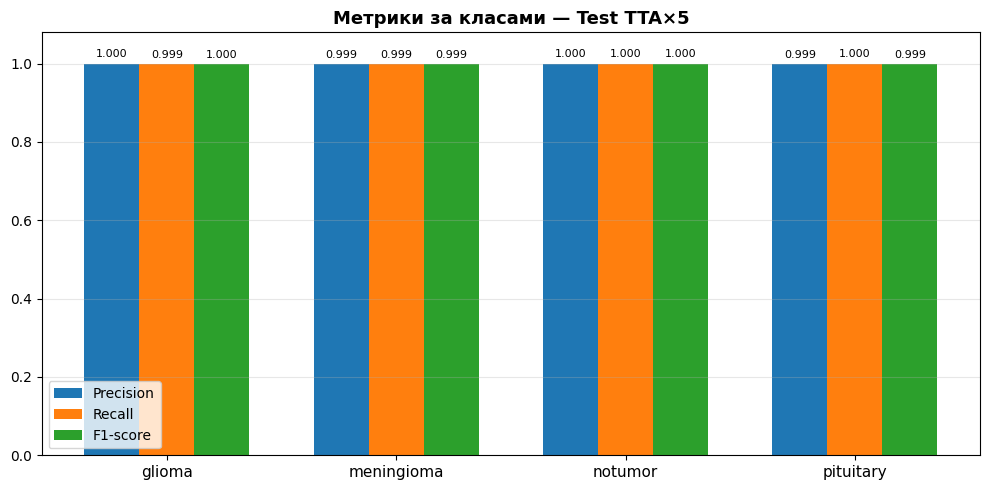

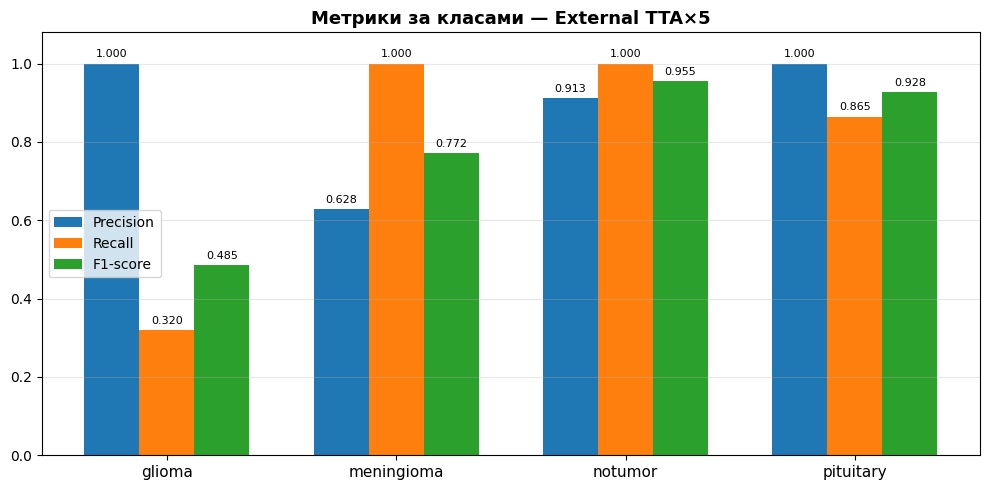

In [ ]:
def plot_per_class(y_true, y_pred, title, save_path=None):
    prec = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec  = recall_score(   y_true, y_pred, average=None, zero_division=0)
    f1   = f1_score(       y_true, y_pred, average=None, zero_division=0)

    x = np.arange(len(CLASS_LABELS))
    w = 0.24

    fig, ax = plt.subplots(figsize=(10, 5))

    b1 = ax.bar(x - w, prec, w, label="Precision")
    b2 = ax.bar(x,     rec,  w, label="Recall")
    b3 = ax.bar(x + w, f1,   w, label="F1-score")

    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_LABELS, fontsize=11)

    ax.set_ylim(0, 1.08)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    ax.set_title(title, fontsize=13, fontweight="bold")

    for bars in (b1, b2, b3):
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

plot_per_class(
    y_test,
    tta_test_preds,
    "Метрики за класами — Test TTA×5",
    OUTPUT_DIR / "per_class_test.png"
)

plot_per_class(
    y_external,
    tta_ext_preds,
    "Метрики за класами — External TTA×5",
    OUTPUT_DIR / "per_class_ext.png"
)

In [ ]:
import time
import json
import joblib
import cv2
from sklearnex import patch_sklearn
patch_sklearn()
from skimage.feature import hog, local_binary_pattern
from skimage.feature import graycomatrix, graycoprops
from skimage.util import img_as_ubyte
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from scipy.stats import loguniform
from joblib import Parallel, delayed

In [ ]:
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_ORIENTATIONS = 9

LBP_POINTS = 24
LBP_RADIUS = 3.0

WAVELET_ALPHA = 1.4


def apply_db4_enhancement(gray, alpha=WAVELET_ALPHA):
    approx, (lh, hl, hh) = pywt.dwt2(gray, "db4")

    details = (
        np.abs(lh[:approx.shape[0], :approx.shape[1]]) +
        np.abs(hl[:approx.shape[0], :approx.shape[1]]) +
        np.abs(hh[:approx.shape[0], :approx.shape[1]])
    )

    enhanced = approx + alpha * details
    enhanced = cv2.resize(enhanced.astype(np.float32), (224, 224))

    mn = enhanced.min()
    mx = enhanced.max()

    return (enhanced - mn) / (mx - mn) if mx > mn else enhanced


def extract_classical_features(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    enh = apply_db4_enhancement(gray)

    # hog
    hog_feat = hog(
        enh,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        transform_sqrt=True,
        block_norm="L2-Hys"
    )

    # lbp
    ubyte = img_as_ubyte(np.clip(enh, 0, 1))

    lbp = local_binary_pattern(
        ubyte,
        LBP_POINTS,
        LBP_RADIUS,
        method="uniform"
    )

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=LBP_POINTS + 2,
        range=(0, LBP_POINTS + 2),
        density=True
    )

    # glcm
    glcm = graycomatrix(
        ubyte,
        [1, 2, 3],
        [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
        symmetric=True,
        normed=True
    )

    glcm_feat = []
    for prop in ("contrast", "dissimilarity", "homogeneity", "energy", "correlation"):
        v = graycoprops(glcm, prop)
        glcm_feat.extend([v.mean(), v.std()])


    coeffs = pywt.wavedec2(enh, "db4", level=WAVELET_LEVELS)
    wav_feat = []

    for c in coeffs:
        for sub in (c if isinstance(c, tuple) else [c]):
            f = sub.ravel()
            wav_feat.extend([
                f.mean(),
                f.std(),
                np.percentile(f, 25),
                np.percentile(f, 75),
                np.abs(f).mean()
            ])

    return np.concatenate([
        hog_feat,
        lbp_hist.astype(np.float32),
        np.array(glcm_feat, dtype=np.float32),
        np.array(wav_feat, dtype=np.float32)
    ])


def load_or_extract(root_dir, split, folder_map=None):
    cache = OUTPUT_DIR / f"{split}_classical.joblib"

  
    if cache.exists():
        d = joblib.load(cache)
        print(f"[{split}] з кешу: {d['X'].shape}")
        return d["X"], d["y"], d["paths"]

    paths = []
    labels = []

    fm = folder_map or {cls: i for i, cls in enumerate(CLASS_LABELS)}

    for folder, label in fm.items():
        d = root_dir / folder

        files = sorted(
            f for ext in ("*.jpg", "*.jpeg", "*.png")
            for f in d.rglob(ext)
        )

        paths.extend(files)
        labels.extend([label] * len(files))

    print(f"[{split}] виділення ознак: {len(paths)} фото...")

    # паралельне виділення ознак
    X = np.vstack(
        Parallel(n_jobs=-1, prefer="threads")(
            delayed(extract_classical_features)(p)
            for p in tqdm(paths, desc=split)
        )
    )

    joblib.dump(
        {
            "X": X,
            "y": np.array(labels, dtype=np.int64),
            "paths": [str(p) for p in paths],
        },
        cache,
        compress=3
    )

    return X, np.array(labels, dtype=np.int64), paths


X_cl_train, y_cl_train, _ = load_or_extract(TRAINING_IMAGES_DIR, "train")
X_cl_test,  _,          _ = load_or_extract(TEST_IMAGES_DIR,     "test")
X_cl_ext,   _,          _ = load_or_extract(
    EXTERNAL_TEST_IMAGES_DIR,
    "external",
    folder_map=EXTERNAL_LABEL_MAP
)

[train] виділення ознак: 32080 фото...


train:   0%|          | 0/32080 [00:00<?, ?it/s]

[test] виділення ознак: 8020 фото...


test:   0%|          | 0/8020 [00:00<?, ?it/s]

[external] виділення ознак: 394 фото...


external:   0%|          | 0/394 [00:00<?, ?it/s]

In [ ]:
@torch.no_grad()
def extract_swin_embeddings(paths):
    model.eval()

    ds = ImagePathDataset(
        [str(p) for p in paths],
        np.zeros(len(paths), dtype=np.int64),
        validation_transform
    )

    ld = DataLoader(
        ds,
        batch_size=64,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    embs = []

    for imgs, _ in tqdm(ld, desc="Swin embeddings"):
        imgs = imgs.to(COMPUTE_DEVICE)
        embs.append(model.swin(imgs).cpu().numpy())

    return np.vstack(embs)


# Swin embeddings
swin_train = extract_swin_embeddings([s[0] for s in train_dataset.samples])
swin_test = extract_swin_embeddings(test_image_paths)
swin_ext = extract_swin_embeddings([str(p) for p in external_paths])


# масштабування класичних ознак і Swin embeddings
cl_scaler = StandardScaler()
swin_scaler = StandardScaler()

X_cl_train_scaled = cl_scaler.fit_transform(X_cl_train)
swin_train_scaled = swin_scaler.fit_transform(swin_train)

X_cl_test_scaled = cl_scaler.transform(X_cl_test)
swin_test_scaled = swin_scaler.transform(swin_test)

X_cl_ext_scaled = cl_scaler.transform(X_cl_ext)
swin_ext_scaled = swin_scaler.transform(swin_ext)


# об’єднання ознак
X_fused_train = np.concatenate([X_cl_train_scaled, swin_train_scaled], axis=1)
X_fused_test = np.concatenate([X_cl_test_scaled, swin_test_scaled], axis=1)
X_fused_ext = np.concatenate([X_cl_ext_scaled, swin_ext_scaled], axis=1)

print(f"Fusion dim: {X_fused_train.shape[1]}")

Swin embeddings:   0%|          | 0/502 [00:00<?, ?it/s]

Swin embeddings:   0%|          | 0/126 [00:00<?, ?it/s]

Swin embeddings:   0%|          | 0/7 [00:00<?, ?it/s]

Fusion dim: 7194


In [ ]:
#SVM
class SafePCA(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=0.95, random_state=None):
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y=None):
        k = self.n_components

        if isinstance(k, float):
            pca = PCA(
                n_components=k,
                svd_solver="full",
                random_state=self.random_state
            )
        else:
            k = max(1, min(int(k), min(X.shape) - 1))

            pca = PCA(
                n_components=k,
                svd_solver="randomized",
                random_state=self.random_state
            )

        self.pca_model = pca.fit(X)

        return self

    def transform(self, X):
        return self.pca_model.transform(X)

    def get_params(self, deep=True):
        return {
            "n_components": self.n_components,
            "random_state": self.random_state
        }

    def set_params(self, **p):
        for k, v in p.items():
            setattr(self, k, v)

        return self


y_train_labels = np.array([lbl for _, lbl in train_dataset.samples])

svm_search = HalvingRandomSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("pca", SafePCA(0.95, SEED)),
        ("svc", SVC(
            kernel="rbf",
            cache_size=2000,
            probability=True,
            random_state=SEED
        )),
    ]),

    {
        "svc__C": loguniform(1e-1, 1e3),
        "svc__gamma": loguniform(1e-4, 1e-1),
    },

    factor=3,
    resource="n_samples",
    min_resources=600,
    max_resources=6000,
    n_candidates=40,
    scoring="accuracy",

    cv=StratifiedKFold(
        3,
        shuffle=True,
        random_state=SEED
    ),

    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)

svm_search.fit(X_fused_train, y_train_labels)

best_svm_params = svm_search.best_params_


svm_model = Pipeline([
    ("scaler", StandardScaler()),

    ("pca", PCA(
        n_components=0.95,
        svd_solver="full",
        random_state=SEED
    )),

    ("svc", SVC(
        kernel="rbf",
        cache_size=2000,
        probability=True,
        random_state=SEED,
        C=best_svm_params["svc__C"],
        gamma=best_svm_params["svc__gamma"]
    )),
])

t0 = time.time()
svm_model.fit(X_fused_train, y_train_labels)

print(f"SVM навчено за {time.time() - t0:.1f} с")

In [ ]:
# KNN
knn_model = Pipeline([
    ("scaler", StandardScaler()),

    ("pca", PCA(
        n_components=200,
        random_state=SEED
    )),

    ("knn", KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        metric="cosine",
        n_jobs=-1
    )),
])

knn_model.fit(X_fused_train, y_train_labels)

In [ ]:
def predict_batched(clf, X, batch=4000):
    preds = [
        clf.predict(X[i:i + batch])
        for i in range(0, len(X), batch)
    ]

    return np.concatenate(preds)


def predict_proba_batched(clf, X, batch=4000):
    probs = [
        clf.predict_proba(X[i:i + batch])
        for i in range(0, len(X), batch)
    ]

    return np.vstack(probs)


# SVM і KNN
svm_test_preds = predict_batched(svm_model, X_fused_test)
knn_test_preds = predict_batched(knn_model, X_fused_test)

svm_ext_preds = predict_batched(svm_model, X_fused_ext)
knn_ext_preds = predict_batched(knn_model, X_fused_ext)


svm_test_probs = predict_proba_batched(svm_model, X_fused_test)
knn_test_probs = knn_model.predict_proba(X_fused_test)

svm_ext_probs = predict_proba_batched(svm_model, X_fused_ext)
knn_ext_probs = knn_model.predict_proba(X_fused_ext)


# ваги 
W = {
    "swin": 0.55,
    "svm": 0.30,
    "knn": 0.15,
}


# Swin TTA 
_, tta_test_preds, _, tta_test_probs = eval_with_tta(
    model,
    test_image_paths,
    y_test,
    n_tta=5
)

_, tta_ext_preds, _, tta_ext_probs = eval_with_tta(
    model,
    [str(p) for p in external_paths],
    y_external,
    n_tta=5
)

ens_test_probs = (
    W["swin"] * tta_test_probs +
    W["svm"]  * svm_test_probs +
    W["knn"]  * knn_test_probs
)

ens_ext_probs = (
    W["swin"] * tta_ext_probs +
    W["svm"]  * svm_ext_probs +
    W["knn"]  * knn_ext_probs
)


ens_test_preds = ens_test_probs.argmax(1)
ens_ext_preds = ens_ext_probs.argmax(1)

In [ ]:
for title, y_true, y_pred in [
    ("TEST — SVM Fusion", y_test, svm_test_preds),
    ("TEST — KNN Fusion", y_test, knn_test_preds),
    ("TEST — Комбінована модель TTA", y_test, ens_test_preds),

    ("EXTERNAL — SVM Fusion", y_external, svm_ext_preds),
    ("EXTERNAL — KNN Fusion", y_external, knn_ext_preds),
    ("EXTERNAL — Комбінована модель TTA", y_external, ens_ext_preds),
]:
    report(y_true, y_pred, title)


TEST — SVM Fusion
              precision    recall  f1-score   support

      glioma     1.0000    0.9995    0.9997      1886
  meningioma     0.9995    0.9989    0.9992      1879
     notumor     1.0000    1.0000    1.0000      2317
   pituitary     0.9990    1.0000    0.9995      1938

    accuracy                         0.9996      8020
   macro avg     0.9996    0.9996    0.9996      8020
weighted avg     0.9996    0.9996    0.9996      8020


TEST — KNN Fusion
              precision    recall  f1-score   support

      glioma     1.0000    0.9995    0.9997      1886
  meningioma     0.9995    0.9984    0.9989      1879
     notumor     1.0000    1.0000    1.0000      2317
   pituitary     0.9985    1.0000    0.9992      1938

    accuracy                         0.9995      8020
   macro avg     0.9995    0.9995    0.9995      8020
weighted avg     0.9995    0.9995    0.9995      8020


TEST — Комбінована модель  TTA
              precision    recall  f1-score   support

     

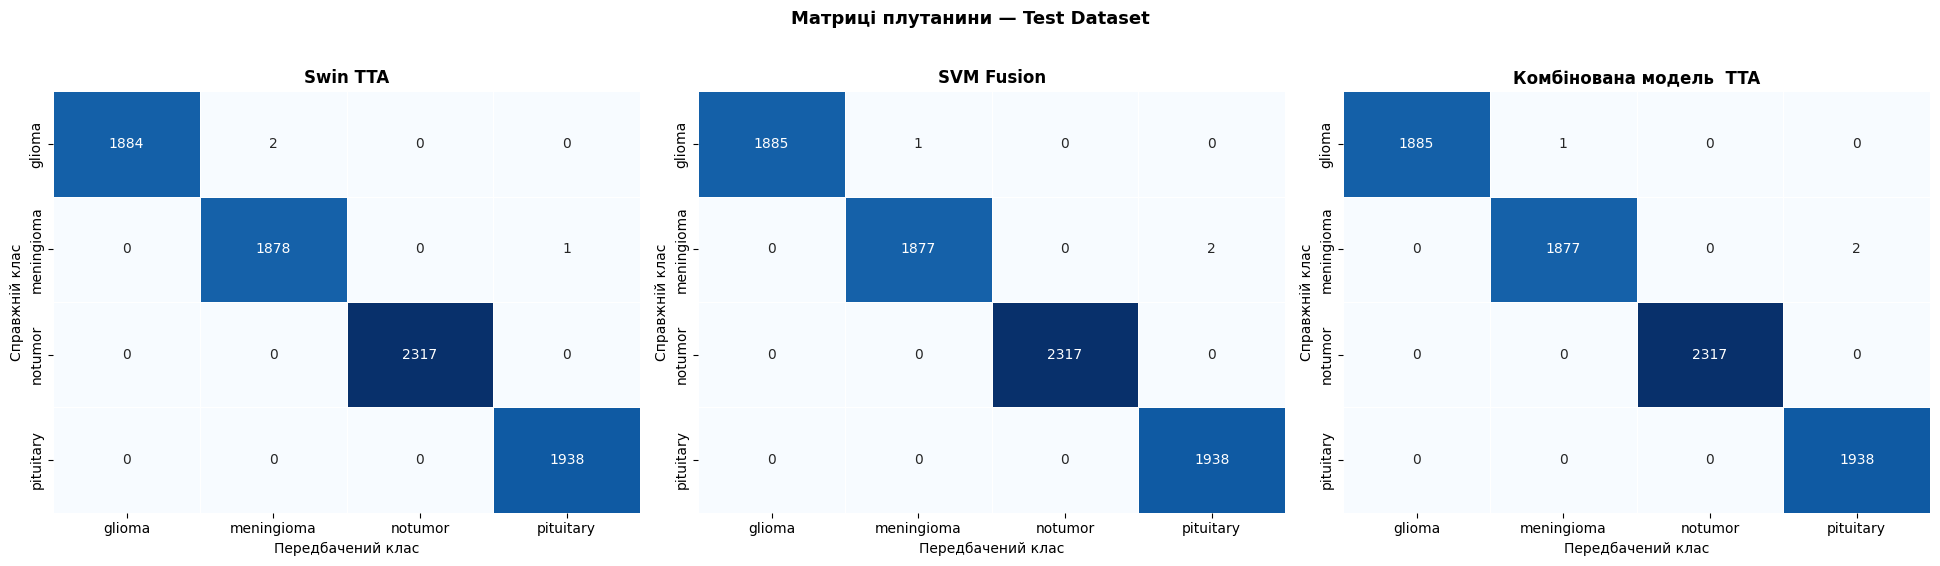

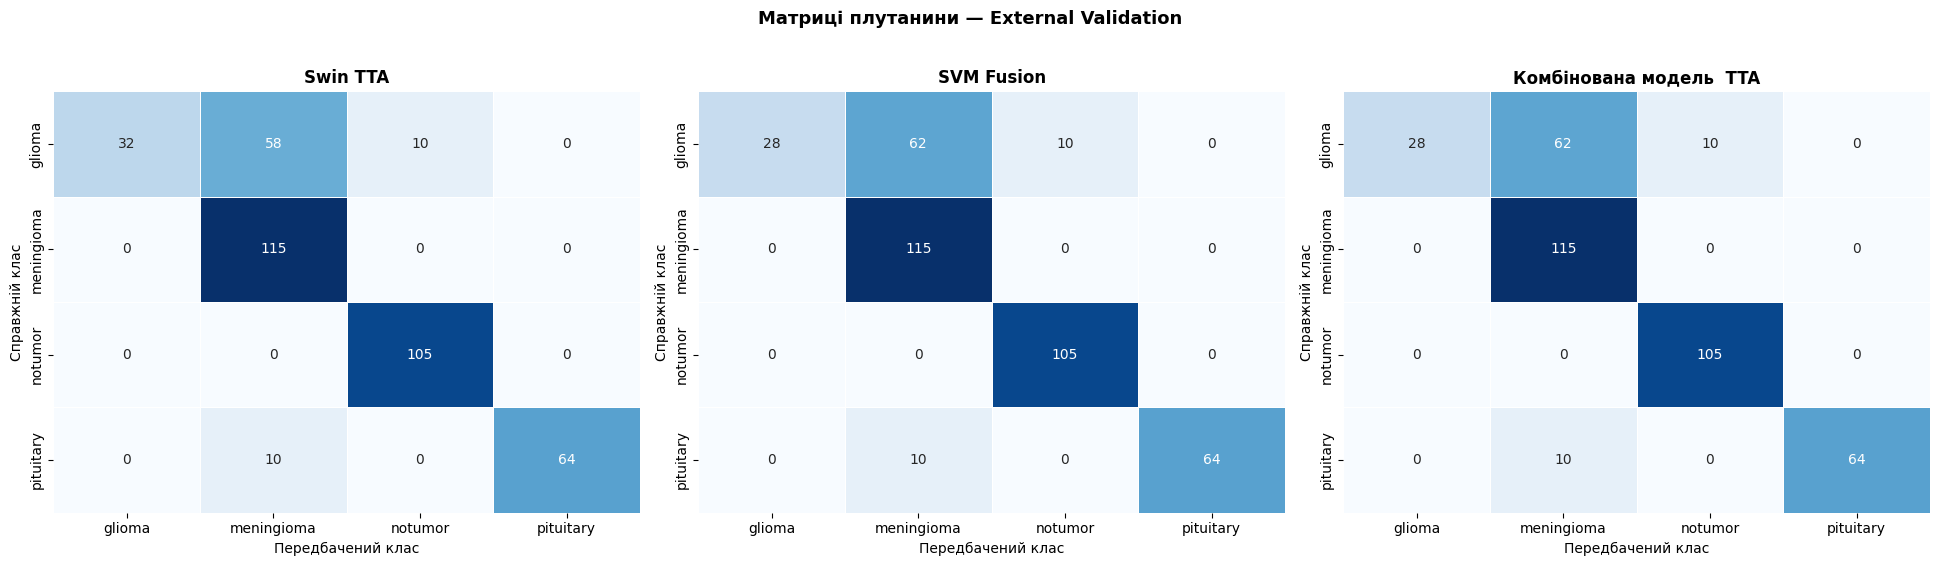

In [ ]:
plot_cm(
    {
        "Swin TTA": (y_test, tta_test_preds),
        "SVM Fusion": (y_test, svm_test_preds),
        "Комбінована модель TTA": (y_test, ens_test_preds),
    },
    CLASS_LABELS,
    "Матриці плутанини — Test Dataset",
    save_path=OUTPUT_DIR / "confusion_test_ensemble.png",
)

plot_cm(
    {
        "Swin TTA": (y_external, tta_ext_preds),
        "SVM Fusion": (y_external, svm_ext_preds),
        "Комбінована модель TTA": (y_external, ens_ext_preds),
    },
    CLASS_LABELS,
    "Матриці плутанини — External Validation",
    save_path=OUTPUT_DIR / "confusion_external_ensemble.png",
)

In [ ]:
all_preds = {
    "Swin TTA": tta_ext_preds,
    "SVM Fusion": svm_ext_preds,
    "KNN Fusion": knn_ext_preds,
    "Комбінована модель TTA": ens_ext_preds,
}

ext_paths_str = [str(p) for p in external_paths]
misclassified = {}

for name, preds in all_preds.items():
    wrong = [
        {
            "path": path,
            "file": Path(path).name,
            "true": CLASS_LABELS[int(yt)],
            "predicted": CLASS_LABELS[int(yp)],
        }
        for path, yt, yp in zip(ext_paths_str, y_external, preds)
        if yt != yp
    ]

    misclassified[name] = wrong

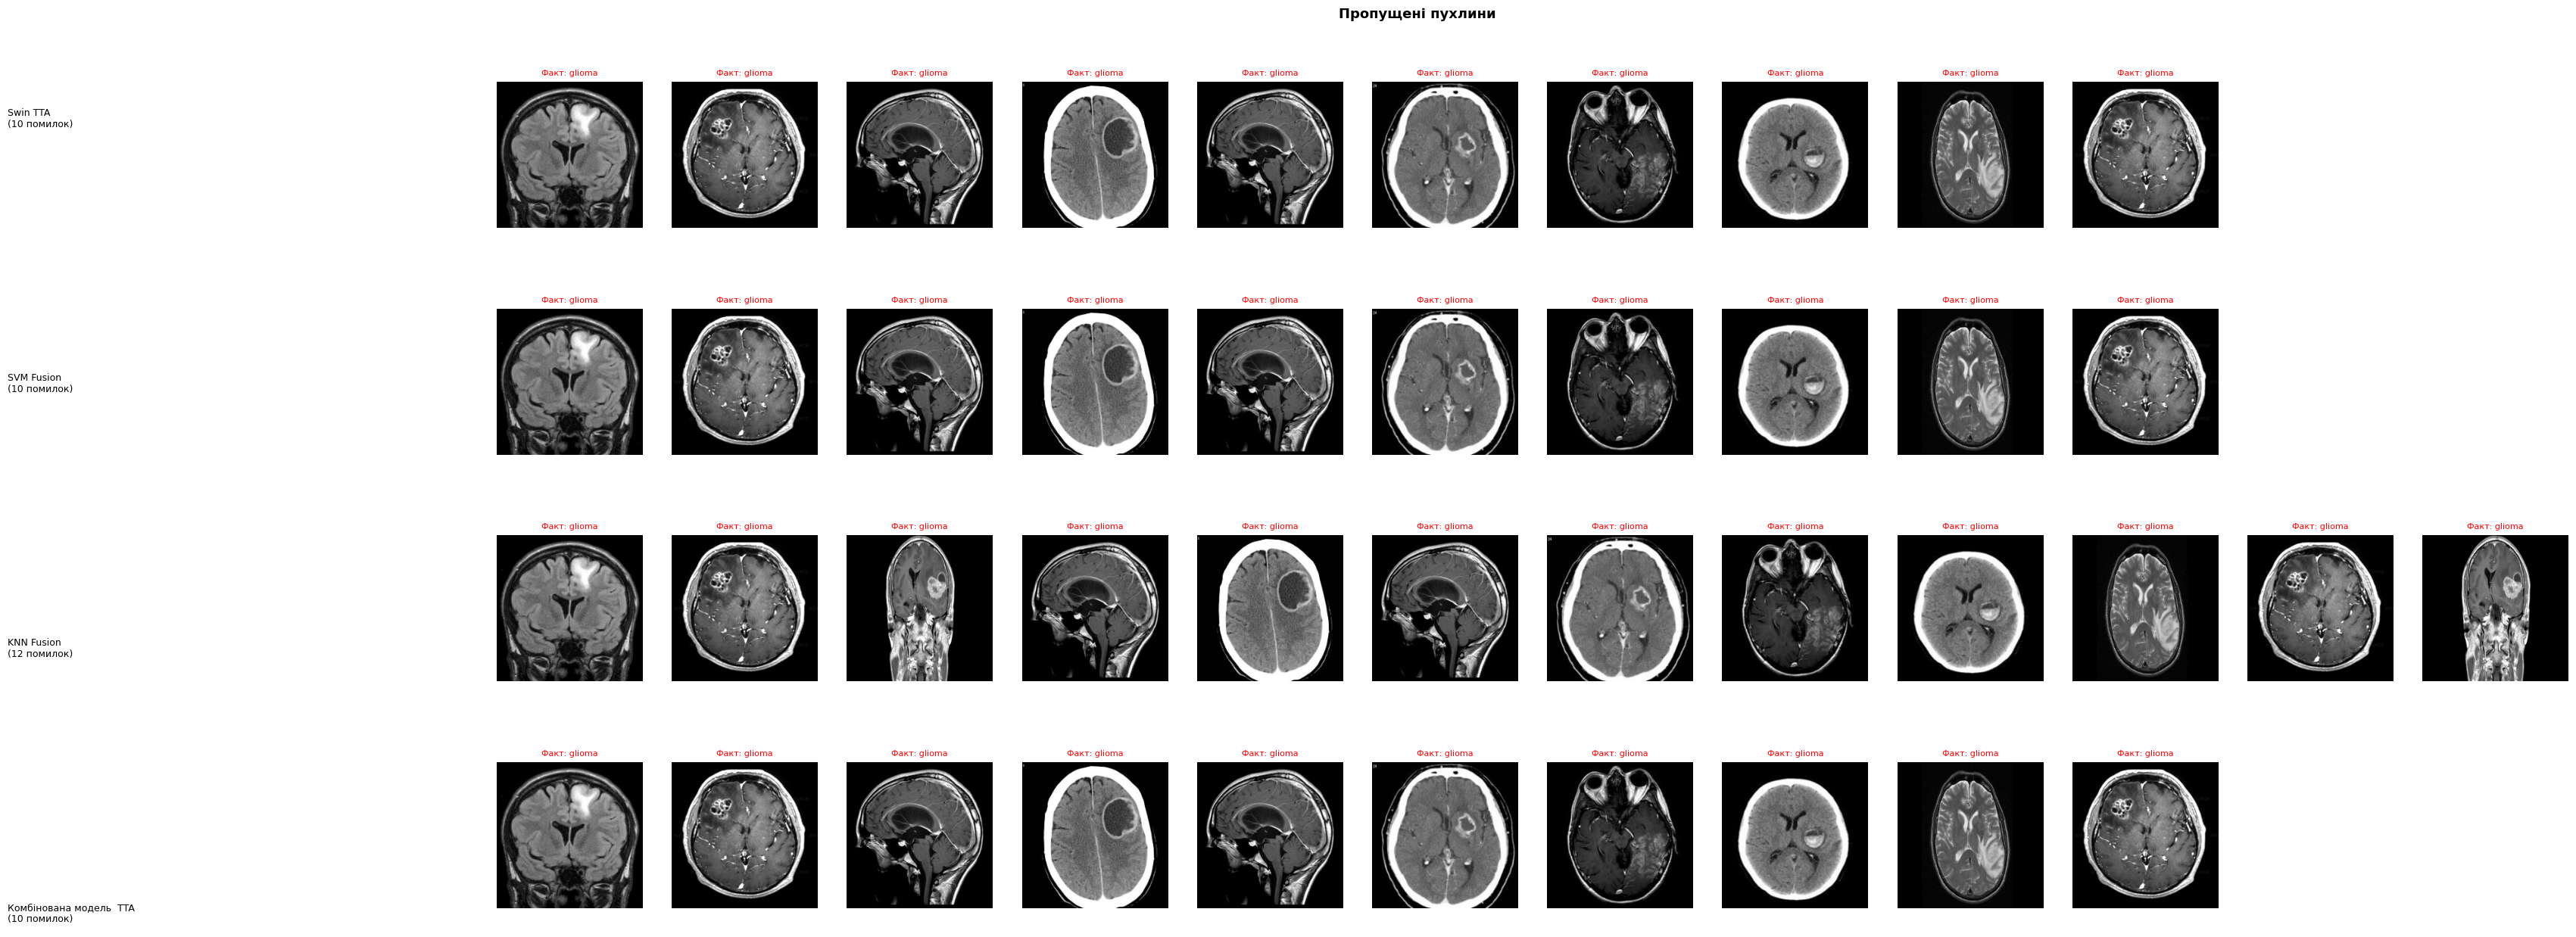

In [ ]:
tumor_classes = {"glioma", "meningioma", "pituitary"}

false_notumor_by_model = {
    name: [
        i for i in wrong
        if i["predicted"] == "notumor" and i["true"] in tumor_classes
    ]
    for name, wrong in misclassified.items()
    if any(
        i["predicted"] == "notumor" and i["true"] in tumor_classes
        for i in wrong
    )
}

n_cols = max(len(v) for v in false_notumor_by_model.values()) or 1
n_rows = len(false_notumor_by_model)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3 * n_cols + 2, 3.5 * n_rows)
)

if n_rows == 1:
    axes = axes[np.newaxis, :]

if n_cols == 1:
    axes = axes[:, np.newaxis]

for row, (model_name, items) in enumerate(false_notumor_by_model.items()):
    for col in range(n_cols):
        ax = axes[row, col]

        if col < len(items):
            item = items[col]

            img = cv2.imread(item["path"])
            img = cv2.resize(img, (224, 224))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax.imshow(img)
            ax.set_title(
                f"Факт: {item['true']}",
                fontsize=8,
                color="red"
            )

        ax.axis("off")

    y_pos = 1 - (row + 0.5) / n_rows

    fig.text(
        0.01,
        y_pos,
        f"{model_name}\n({len(items)} помилок)",
        fontsize=9,
        va="center",
        ha="left",
    )

plt.suptitle("Пропущені пухлини", fontsize=13, fontweight="bold")
plt.subplots_adjust(left=0.18, top=0.93)

plt.savefig(
    OUTPUT_DIR / "false_notumor_all.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()